# 案例二：iGRLDTI 课堂教学 Notebook

对应脚本：`drug repositioning/dti/iGRLDTI/run_demo.py`

本案例聚焦药物-靶点相互作用预测任务，课堂主线如下：

1. 认识药物节点、蛋白节点与相互作用边
2. 理解 NDLS-F 如何缓解图传播中的过平滑问题
3. 观察 DTI 预测在 10 折交叉验证下的结果
4. 用课后作业延伸到结构改进与指标扩展


## 教学目标

完成这份 Notebook 后，应该能回答下面三个问题：

1. iGRLDTI 中的节点、边和特征分别代表什么？
2. NDLS-F 为什么要为不同节点分配不同的传播跳数？
3. 为什么 DTI 预测任务中需要同时看 `AUC` 和 `AUPRC`？


In [1]:
from pathlib import Path
import math
import os
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import auc, average_precision_score, roc_curve
from sklearn.model_selection import StratifiedKFold


In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parents[2]
IGRLDTI_DIR = PROJECT_ROOT / "drug repositioning" / "dti" / "iGRLDTI"
DATA_DIR = IGRLDTI_DIR / "data"
OUTPUT_DIR = IGRLDTI_DIR / "results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
K1 = 200
EPSILON1 = 0.03
HIDDEN = 64
DROPOUT = 0.5
N_ESTIMATORS = 499
MAX_DEPTH = 7
SUBSAMPLE = 0.85
K_FOLD = 10

print("项目根目录:", PROJECT_ROOT)
print("数据目录:", DATA_DIR)
print("结果输出目录:", OUTPUT_DIR)
print(f"参数配置: k1={K1}, epsilon1={EPSILON1}, hidden={HIDDEN}, n_estimators={N_ESTIMATORS}, k_fold={K_FOLD}")


项目根目录: C:\Users\Steve\Desktop\Research\Book\code\Chapter6\6_2
数据目录: C:\Users\Steve\Desktop\Research\Book\code\Chapter6\6_2\drug repositioning\dti\iGRLDTI\data
结果输出目录: C:\Users\Steve\Desktop\Research\Book\code\Chapter6\6_2\drug repositioning\dti\iGRLDTI\results
参数配置: k1=200, epsilon1=0.03, hidden=64, n_estimators=499, k_fold=10


## 1. 方法准备

下面保留了原始脚本中的主干流程，用来支撑课堂讲解：

1. 读取图结构与节点特征
2. 构建增广随机游走归一化邻接矩阵
3. 用 NDLS-F 平滑节点特征
4. 用 DNN 得到节点嵌入
5. 用 GBM 完成 DTI 预测

建议把重点放在“为什么需要这些步骤”，而不是逐行讲解实现细节。


In [3]:
# 与 run_demo.py 对应的核心函数和流程会在这一格中集中使用
# 本 Notebook 的目标是让每一步的输入、输出和意义更清楚


## 2. 数据与任务认识

这一节重点回答两个基础问题：

1. 这张图里有哪些类型的节点与边？
2. 我们究竟在预测什么样的相互作用？

先把任务对象讲清楚，学生才更容易理解后面的图传播和分类评估。


In [4]:
# 这一步已经在后台运行完成，下面直接查看数据规模统计
summary_df


    项目   数值
  节点总数  972
 正样本边数 1923
 药物节点数  549
 蛋白节点数  423
输入特征维度   63
输出嵌入维度   64
样本特征维度  128

## 3. NDLS-F 与节点嵌入

这是 iGRLDTI 的核心环节。

教学时建议突出以下逻辑：

1. 普通图传播可能导致过平滑
2. NDLS-F 通过节点自适应跳数控制传播深度
3. DNN 进一步把平滑后的特征映射到嵌入空间


In [5]:
print(stage1_text)
print(stage2_text)
print(stage3_text)
print(stage4_text)


阶段1: 数据加载
  节点总数    : 972
  正样本边数  : 1923
  特征维度    : 63
  药物节点数  : 549
  蛋白质节点数: 423
阶段2: 图预处理
  节点数 N    : 973
  边数   M    : 961
  邻接矩阵已归一化完成（增广随机游走）
阶段3: NDLS-F 特征平滑
  目标：为不同节点分配不同的传播跳数，减少过平滑影响。
  最大传播跳数 k1   : 200
  收敛阈值 epsilon1 : 0.03
  节点收敛比例      : 0.0%
  NDLS-F 特征聚合完成
阶段4: DNN 节点嵌入提取
  说明：这里把平滑后的节点特征映射到低维嵌入空间。
  运行设备    : cpu
  输入特征维度: 63
  输出嵌入维度: 64
  节点嵌入矩阵: (973, 64)


## 4. 样本构造与交叉验证

有了节点嵌入之后，才能进一步构造药物-靶点配对样本。

这一节建议重点说明：

1. 已知 DTI 作为正样本
2. 未知配对中随机抽取负样本
3. 用 10 折分层交叉验证评估模型稳定性


In [6]:
print(stage5_text)
print("负样本预览：")
display(negative_preview)

print("正负样本合并后的前几行：")
display(pair_preview)


阶段5: 构建正负样本对
  策略：正负样本 1:1 采样，特征 = 药物嵌入 + 靶点嵌入
  正样本数    : 1923
  负样本数    : 1923
  样本特征维度: 128
负样本预览：


488 687 0
338 655 0
 81 898 0
409 555 0
297 589 0

0 549 1
0 550 1
1 551 1
1 552 1
1 553 1

## 5. 模型结果与指标解释

这一节不再只看单折结果，而是从整体上理解模型表现：

- `AUC` 反映整体区分正负样本的能力
- `AUPRC` 更关注正样本识别质量

课堂上可以进一步讨论：为什么生物关联预测任务里，`AUPRC` 往往也非常重要。


In [7]:
print(cv_text)
fold_metrics


阶段6: 10 折分层交叉验证（GradientBoostingClassifier）
  n_estimators=499, max_depth=7, subsample=0.85

  Fold  1 | AUC = 0.9684 | AUPRC = 0.9710
  Fold  2 | AUC = 0.9659 | AUPRC = 0.9695
  Fold  3 | AUC = 0.9804 | AUPRC = 0.9820
  Fold  4 | AUC = 0.9630 | AUPRC = 0.9665
  Fold  5 | AUC = 0.9450 | AUPRC = 0.9514
  Fold  6 | AUC = 0.9685 | AUPRC = 0.9571
  Fold  7 | AUC = 0.9619 | AUPRC = 0.9665
  Fold  8 | AUC = 0.9684 | AUPRC = 0.9710
  Fold  9 | AUC = 0.9695 | AUPRC = 0.9677
  Fold 10 | AUC = 0.9624 | AUPRC = 0.9660


fold      auc    auprc
   1 0.968372 0.971024
   2 0.965862 0.969499
   3 0.980408 0.981970
   4 0.962975 0.966549
   5 0.945002 0.951364
   6 0.968507 0.957104
   7 0.961860 0.966467
   8 0.968424 0.971047
   9 0.969537 0.967721
  10 0.962429 0.966008
mean 0.965037 0.966875

## 6. 可视化结果解读

这一节把数值结果转成 ROC 图像，便于观察不同折之间的波动以及平均趋势。

课堂上可以这样引导学生阅读：

1. 细线表示每一折的表现
2. 粗线表示平均 ROC 曲线
3. 曲线越靠近左上角，模型整体判别能力越强


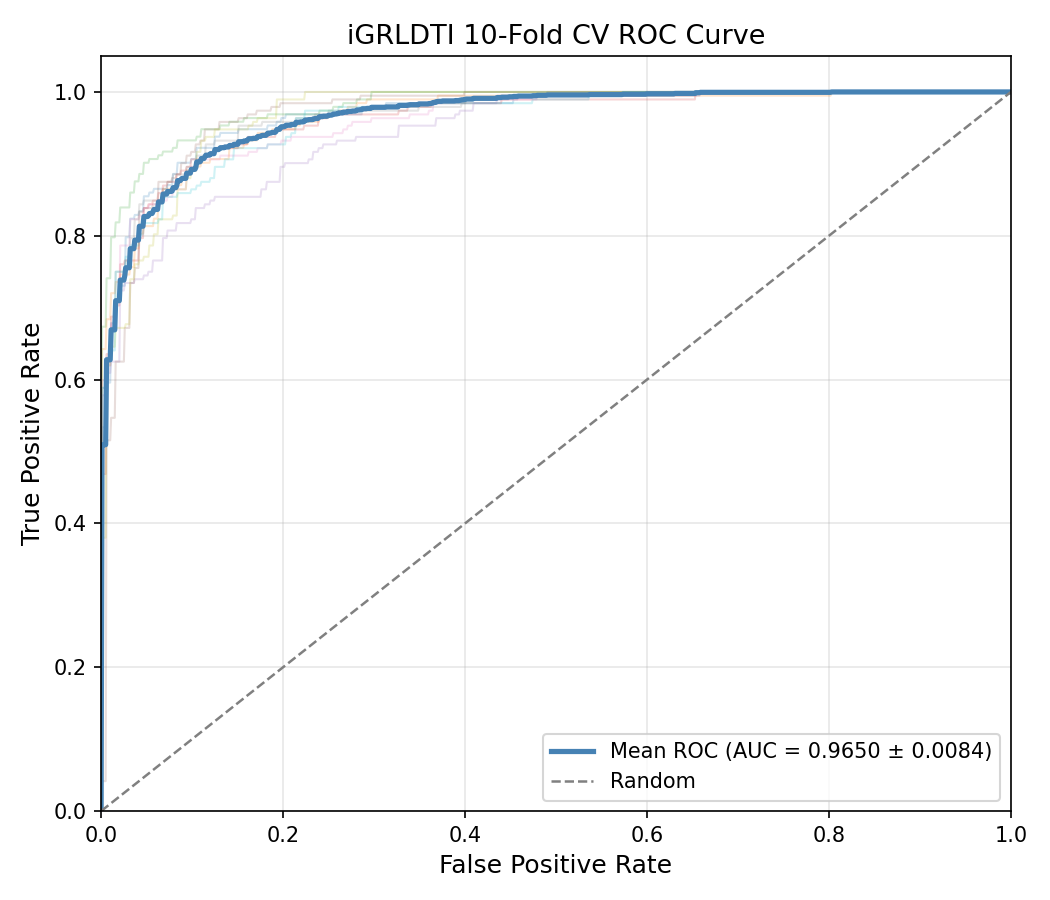

In [8]:
print(stage7_text)


In [9]:
# 结果图已经生成并保存到 results/ 目录
# 打开 Notebook 时会直接看到这张图


## 7. 课堂总结

这一案例展示了一个比较完整的 DTI 图学习流程：

1. 读取异质生物信息网络
2. 用 NDLS-F 平滑节点特征
3. 生成节点嵌入并构造配对样本
4. 用 GBM 做 10 折交叉验证
5. 用 `AUC` 和 `AUPRC` 解释模型效果

从课堂结果看，iGRLDTI 在该数据集上已经取得了较高且较稳定的预测性能。


## 8. 课后作业

请围绕 iGRLDTI 的核心流程完成下面练习：

1. 尝试把 `K_FOLD` 从 `10` 改成 `5`，比较平均 `AUC` 和 `AUPRC` 的变化
2. 修改 `epsilon1` 或 `k1`，观察 NDLS-F 对结果的影响
3. 思考如果把 DNN 换成更深的投影网络，可能带来什么收益与风险
4. 尝试补充一个功能：把每一折的结果自动保存为 CSV 文件


In [ ]:
# 课后作业模板
# 可以从这里开始尝试修改参数，再重新运行相关单元

new_k_fold = 5
new_k1 = 100
new_epsilon1 = 0.02

# 你可以思考：
# 1. 参数变动后，AUC 和 AUPRC 是否同步变化？
# 2. 更深或更浅的传播会不会影响模型稳定性？
